In [ ]:
#Part a) EDA
# i)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

data_path="bank-full.csv"
df = pd.read_csv(data_path,sep=';')

print("Shape:", df.shape)
print("\nData Types:")
print(df.dtypes)

Shape: (45211, 17)

Data Types:
age          int64
job            str
marital        str
education      str
default        str
balance      int64
housing        str
loan           str
contact        str
day          int64
month          str
duration     int64
campaign     int64
pdays        int64
previous     int64
poutcome       str
y              str
dtype: object


In [24]:
print("\nFirst 5 Rows:")
print(df.head())

num_features = df.select_dtypes(include=['int64', 'float64']).shape[1]
cat_features = df.select_dtypes(include=['object', 'category','str']).shape[1]  #added str to avoid a warning

print(f"\nNumerical features: {num_features}")
print(f"Categorical features: {cat_features}")


First 5 Rows:
   age           job  marital  education default  balance housing loan  \
0   58    management  married   tertiary      no     2143     yes   no   
1   44    technician   single  secondary      no       29     yes   no   
2   33  entrepreneur  married  secondary      no        2     yes  yes   
3   47   blue-collar  married    unknown      no     1506     yes   no   
4   33       unknown   single    unknown      no        1      no   no   

   contact  day month  duration  campaign  pdays  previous poutcome   y  
0  unknown    5   may       261         1     -1         0  unknown  no  
1  unknown    5   may       151         1     -1         0  unknown  no  
2  unknown    5   may        76         1     -1         0  unknown  no  
3  unknown    5   may        92         1     -1         0  unknown  no  
4  unknown    5   may       198         1     -1         0  unknown  no  

Numerical features: 7
Categorical features: 10


In [25]:
# ii)
# drop duration since it is not known at the time we are predicting
try:
    df = df.drop(columns=['duration'])
except KeyError:
    pass

yes_percent = df[df["y"]=="yes"].shape[0]/df.shape[0]*100
print (f'Percentage of y=="yes": {yes_percent:.2f}%')
print (f"Trivial Classifier Accuracy: {100-yes_percent:.2f}%")

Percentage of y=="yes": 11.70%
Trivial Classifier Accuracy: 88.30%


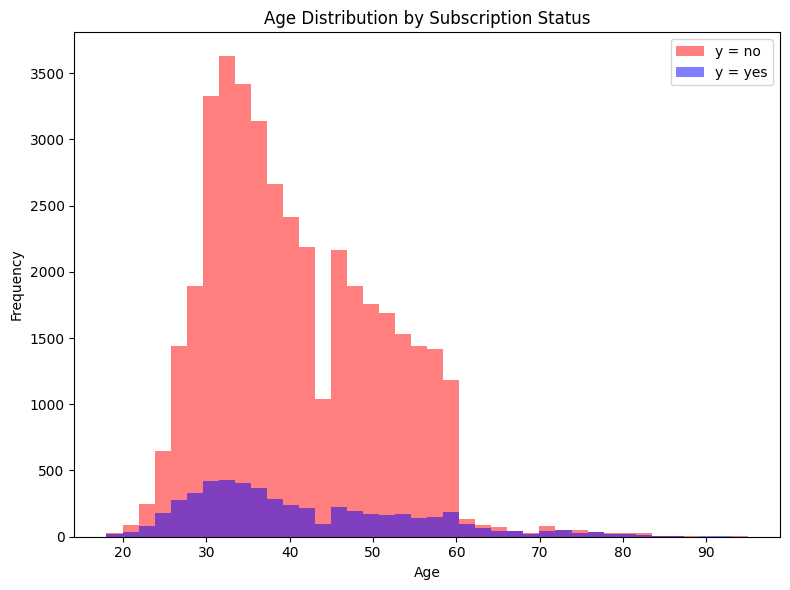

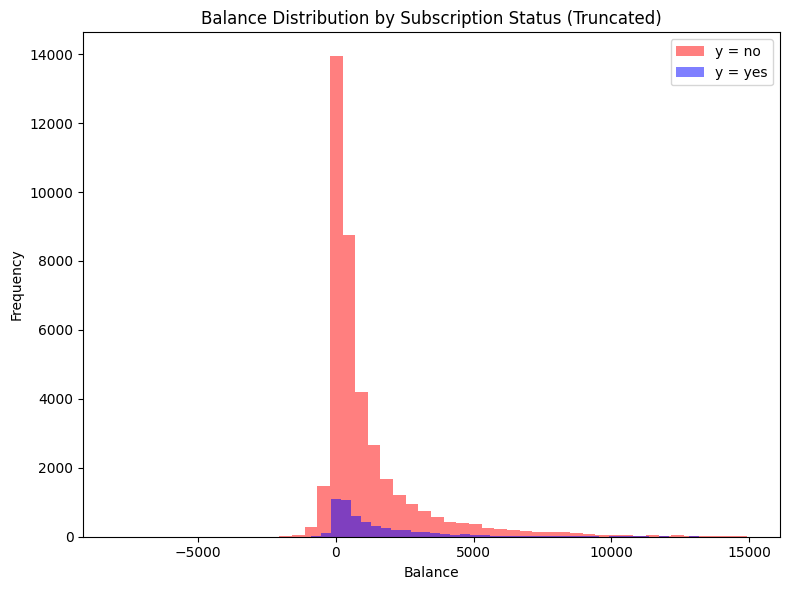

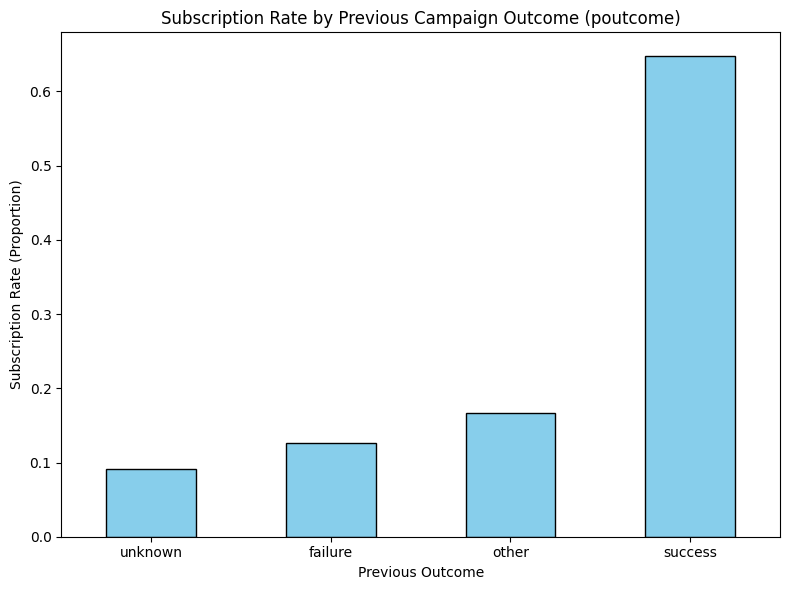

In [ ]:
# iv)
df['y'] = (df['y'] == 'yes').astype(int)

plt.figure(figsize=(8, 6))
plt.hist(df[df['y'] == 0]['age'], bins=40, alpha=0.5, label='y = no', color='red')
plt.hist(df[df['y'] == 1]['age'], bins=40, alpha=0.5, label='y = yes', color='blue')
plt.title('Age Distribution by Subscription Status')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.legend()
plt.tight_layout()
plt.show()


plt.figure(figsize=(8, 6))
# limit the x-axis for balance because it has extreme outliers 
plt.hist(df[(df['y'] == 0) & (df['balance'] < 15000)]['balance'], bins=50, alpha=0.5, label='y = no', color='red')
plt.hist(df[(df['y'] == 1) & (df['balance'] < 15000)]['balance'], bins=50, alpha=0.5, label='y = yes', color='blue')
plt.title('Balance Distribution by Subscription Status')
plt.xlabel('Balance')
plt.ylabel('Frequency')
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 6))

poutcome_rate = df.groupby('poutcome')['y'].mean().sort_values()

poutcome_rate.plot(kind='bar', color='skyblue', edgecolor='black')
plt.title('Subscription Rate by Previous Campaign Outcome (poutcome)')
plt.xlabel('Previous Outcome')
plt.ylabel('Subscription Rate (Proportion)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [27]:
# b)
# i) Already did binary conversion in a) iv)
from sklearn.model_selection import train_test_split

# features and target
X = df.drop('y', axis=1)
y = df['y']

# Encode before splitting
X_encoded = pd.get_dummies(X, drop_first=True)

# 60% Train, 40% Temp
X_train, X_temp, y_train, y_temp = train_test_split(X_encoded, y, test_size=0.4, random_state=42, stratify=y)

# 20% Val, 20% Test
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)

print("Original Dataset Class Balance:\n", y.value_counts(normalize=True))
print("\nTrain Set Class Balance:\n",      y_train.value_counts(normalize=True))
print("\nValidation Set Class Balance:\n", y_val.value_counts(normalize=True))
print("\nTest Set Class Balance:\n",       y_test.value_counts(normalize=True))

Original Dataset Class Balance:
 y
0    0.883015
1    0.116985
Name: proportion, dtype: float64

Train Set Class Balance:
 y
0    0.883027
1    0.116973
Name: proportion, dtype: float64

Validation Set Class Balance:
 y
0    0.88299
1    0.11701
Name: proportion, dtype: float64

Test Set Class Balance:
 y
0    0.883003
1    0.116997
Name: proportion, dtype: float64


In [28]:
# ii) done in i)
print(f"Original number of features (excluding target): {X.shape[1]}")
print(f"Number of features after one-hot encoding: {X_encoded.shape[1]}")

Original number of features (excluding target): 15
Number of features after one-hot encoding: 41


In [ ]:
# c)
# i)
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

dt = DecisionTreeClassifier(max_depth=3, random_state=42)
dt.fit(X_train, y_train)

y_train_pred = dt.predict(X_train)
y_val_pred = dt.predict(X_val)

train_accuracy = accuracy_score(y_train, y_train_pred)
val_accuracy = accuracy_score(y_val, y_val_pred)

print(f"Training Accuracy:   {train_accuracy:.4f}")
print(f"Validation Accuracy: {val_accuracy:.4f}")

Training Accuracy:   0.8923
Validation Accuracy: 0.8927


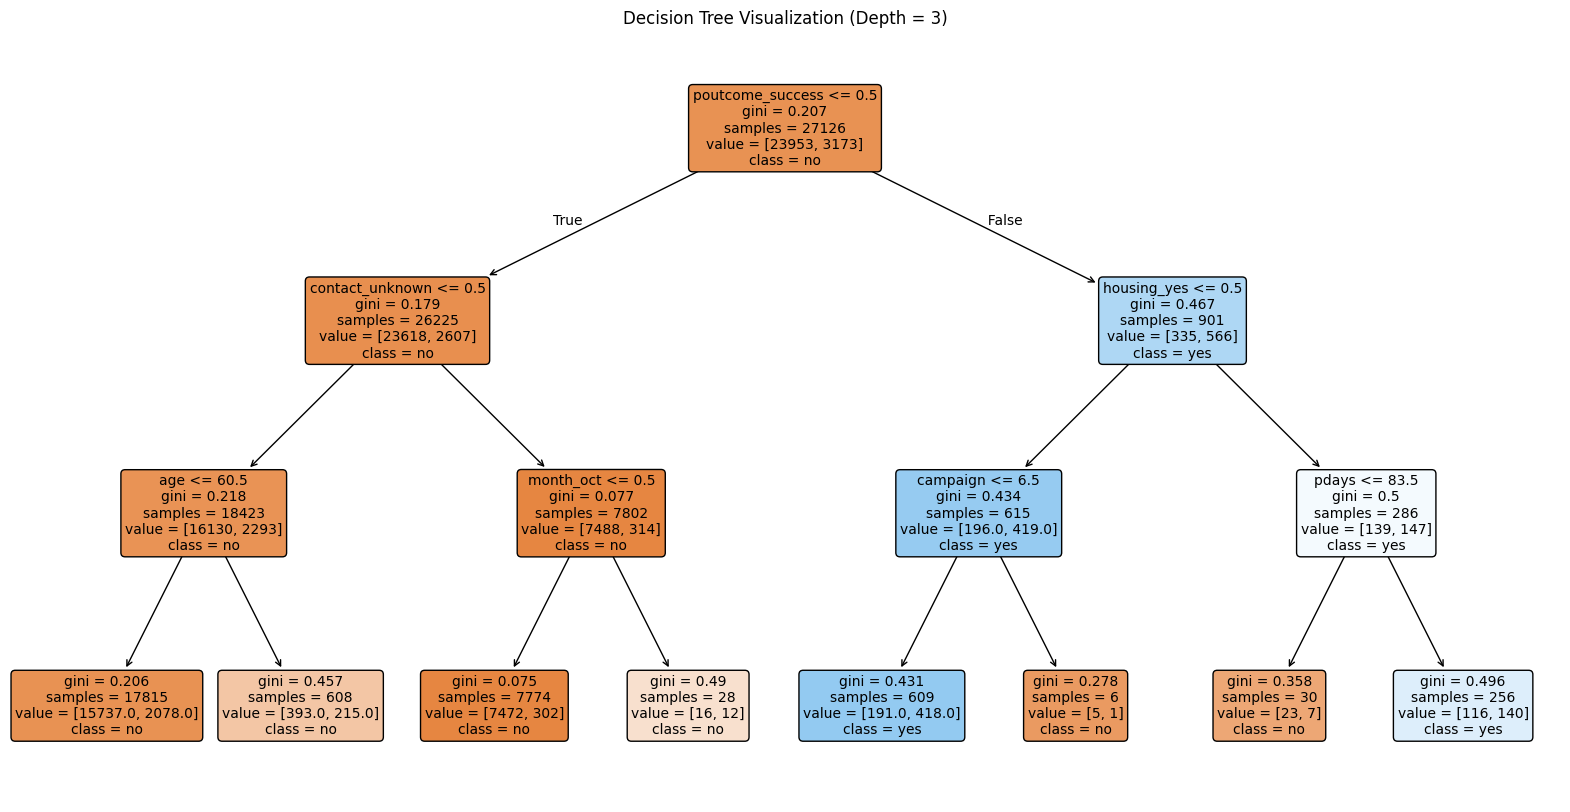

In [30]:
# ii)
from sklearn.tree import DecisionTreeClassifier, plot_tree

plt.figure(figsize=(20, 10)) 
plot_tree(
    dt, 
    feature_names=X_train.columns, 
    class_names=['no', 'yes'], # 'no' is index 0, 'yes' is index 1
    filled=True,               # Colors nodes based on the majority class
    rounded=True,              # Rounds node edges
    fontsize=10                # Adjust font size for readability
)

plt.title("Decision Tree Visualization (Depth = 3)")
plt.show()

#1st
If poutcome_success <= 0.5 

    then go to left.

    #2nd

    if contact unknown <= 0.5

        then go left.

    else

        go to right

else

    go to right.

    #3rd split

    if housing_yes <= 0.5

        then go to left

    else
    
        go to right

In [ ]:
# d)
# i)
max_depths = [1, 2, 3, 5, 7, 10, 15, 20, None]
results = []

for depth in max_depths:

    clf = DecisionTreeClassifier(max_depth=depth, random_state=42)

    clf.fit(X_train, y_train)

    y_train_pred = clf.predict(X_train)
    y_val_pred = clf.predict(X_val)

    train_acc = accuracy_score(y_train, y_train_pred)
    val_acc = accuracy_score(y_val, y_val_pred)

    results.append({
        'Max Depth': 'None (Unlimited)' if depth is None else depth,
        'Train Accuracy': round(train_acc, 4),
        'Validation Accuracy': round(val_acc, 4)
    })

# Convert results to a DataFrame and print
results_df = pd.DataFrame(results)
print(results_df.to_string(index=False))

       Max Depth  Train Accuracy  Validation Accuracy
               1          0.8915               0.8924
               2          0.8915               0.8924
               3          0.8923               0.8927
               5          0.8938               0.8923
               7          0.8984               0.8932
              10          0.9067               0.8911
              15          0.9281               0.8860
              20          0.9513               0.8714
None (Unlimited)          1.0000               0.8253


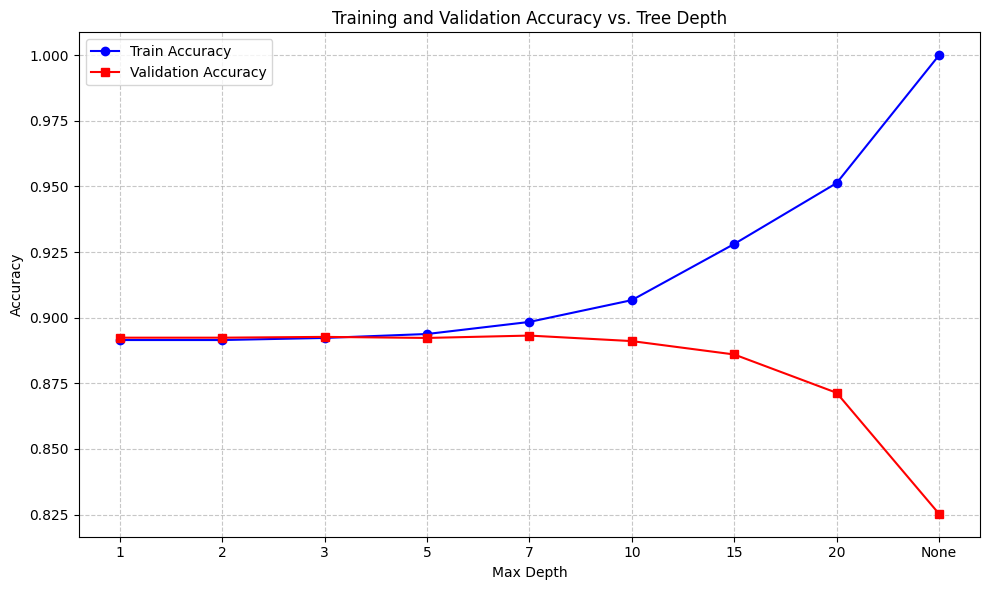

In [ ]:
# ii)
# make a list of numbers from depth (avoid None)
x_positions = range(len(max_depths))

train_accs = [res['Train Accuracy'] for res in results]
val_accs = [res['Validation Accuracy'] for res in results]

plt.figure(figsize=(10, 6))
plt.plot(x_positions, train_accs, label='Train Accuracy', marker='o', color='blue')
plt.plot(x_positions, val_accs, label='Validation Accuracy', marker='s', color='red')

depth_labels = [str(d) for d in max_depths] 
plt.xticks(ticks=x_positions, labels=depth_labels)

plt.title('Training and Validation Accuracy vs. Tree Depth')
plt.xlabel('Max Depth')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()

plt.show()

Validation accuracy peaks at 7: 89.32%. The graph behaves as expected: low depths have very similar trainning and validation accuracy as the model has high bias and low variance(it is too simple for the data) and high depths have low bias but high variance since it learns the trainning data and overfits.

In [ ]:
# e)
# i)
from sklearn.model_selection import KFold, cross_val_score

max_depths = [1, 2, 3, 5, 7, 10, 15, 20, None]
kf = KFold(n_splits=5, shuffle=True, random_state=42)

cv_results = []
for depth in max_depths:
    clf = DecisionTreeClassifier(max_depth=depth, random_state=42)
    
    scores = cross_val_score(clf, X_train, y_train, cv=kf, scoring='accuracy')

    mean_acc = np.mean(scores)
    std_acc = np.std(scores)

    cv_results.append({
        'Max Depth': 'None' if depth is None else depth,
        'Mean CV Accuracy': round(mean_acc, 4),
        'CV Std Dev': round(std_acc, 4)
    })

cv_df = pd.DataFrame(cv_results)
print(cv_df.to_string(index=False))

Max Depth  Mean CV Accuracy  CV Std Dev
        1            0.8915      0.0027
        2            0.8915      0.0027
        3            0.8916      0.0030
        5            0.8905      0.0031
        7            0.8901      0.0023
       10            0.8875      0.0024
       15            0.8837      0.0034
       20            0.8693      0.0048
     None            0.8286      0.0037


In [36]:
# ii)
best_idx = cv_df['Mean CV Accuracy'].idxmax()
best_depth_val = cv_df.loc[best_idx, 'Max Depth']
best_depth = None if best_depth_val == 'None' else int(best_depth_val)

print(f"Best depth chosen by Cross-Validation: {best_depth}")

final_clf = DecisionTreeClassifier(max_depth=best_depth, random_state=42)
final_clf.fit(X_train, y_train)

y_test_pred = final_clf.predict(X_test)
test_accuracy = accuracy_score(y_test, y_test_pred)

print(f"Final Test Accuracy at depth {best_depth}: {round(test_accuracy, 4)}")

Best depth chosen by Cross-Validation: 3
Final Test Accuracy at depth 3: 0.8972


Although this does not exactly match part d, it already indicated that 3 was one of the best (7 was 0.05% better than 3 in single split)

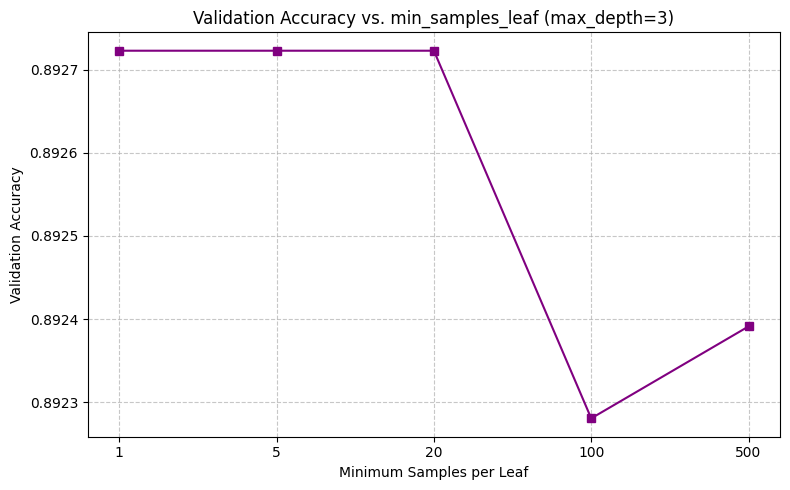

1. Best min_samples_leaf based on validation: 1
2. Final Test Accuracy (depth=3, min_samples_leaf=1): 0.8972


In [37]:
# f)
# i)
min_samples_leaf_vals = [1, 5, 20, 100, 500]
val_accuracies = []

# use best depth from part e)
for msl in min_samples_leaf_vals:
    clf = DecisionTreeClassifier(
        max_depth=best_depth, 
        min_samples_leaf=msl, 
        random_state=42
    )

    clf.fit(X_train, y_train)
    y_val_pred = clf.predict(X_val)
    val_acc = accuracy_score(y_val, y_val_pred)
    val_accuracies.append(val_acc)

plt.figure(figsize=(8, 5))
# Converting the values to strings ensures they are spaced evenly on the axis
plt.plot([str(v) for v in min_samples_leaf_vals], val_accuracies, marker='s', color='purple')
plt.title(f'Validation Accuracy vs. min_samples_leaf (max_depth={best_depth})')
plt.xlabel('Minimum Samples per Leaf')
plt.ylabel('Validation Accuracy')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

best_msl_idx = val_accuracies.index(max(val_accuracies))
best_msl = min_samples_leaf_vals[best_msl_idx]

print(f"1. Best min_samples_leaf based on validation: {best_msl}")

final_clf = DecisionTreeClassifier(
    max_depth=best_depth, 
    min_samples_leaf=best_msl, 
    random_state=42
)
final_clf.fit(X_train, y_train)

y_test_pred = final_clf.predict(X_test)
final_test_acc = accuracy_score(y_test, y_test_pred)

print(f"2. Final Test Accuracy (depth={best_depth}, min_samples_leaf={best_msl}): {round(final_test_acc, 4)}")

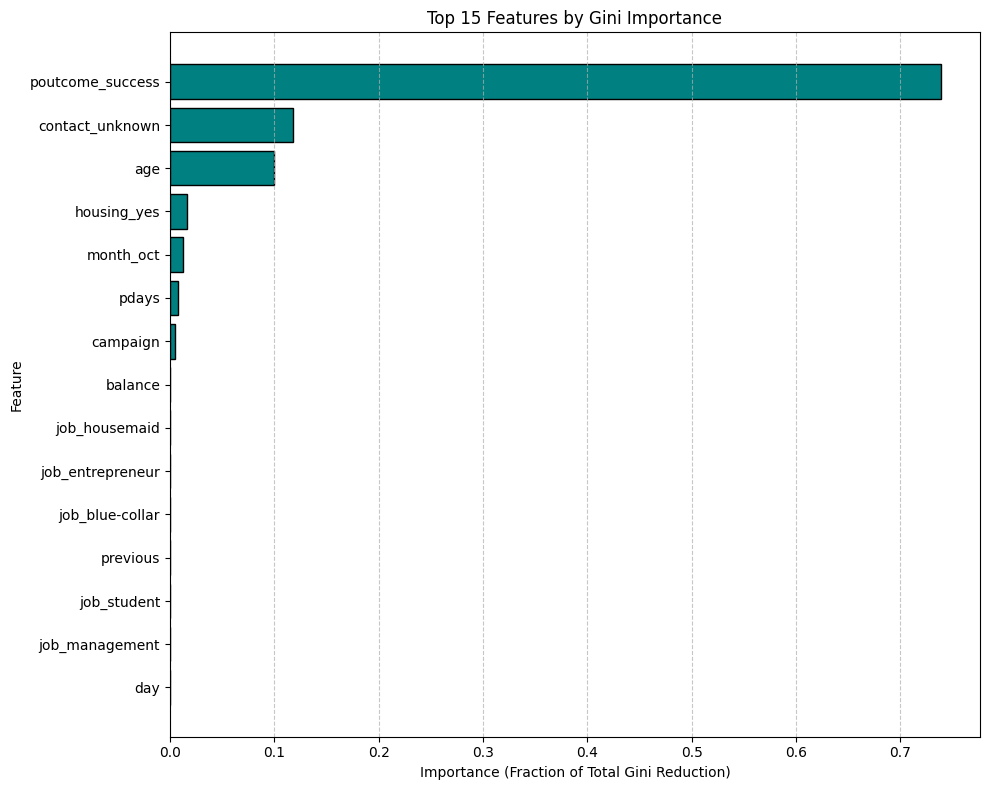

In [38]:
# g)
# i)
importances = final_clf.feature_importances_
importance_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': importances
})

top_15_features = importance_df.sort_values(by='Importance', ascending=False).head(15)
top_15_sorted_for_plot = top_15_features.sort_values(by='Importance', ascending=True)

plt.figure(figsize=(10, 8))
plt.barh(top_15_sorted_for_plot['Feature'], top_15_sorted_for_plot['Importance'], color='teal', edgecolor='black')
plt.title('Top 15 Features by Gini Importance')
plt.xlabel('Importance (Fraction of Total Gini Reduction)')
plt.ylabel('Feature')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

ii) Previous outcome, contact, and age are by far the most important features. That matches the expected correlation we saw in part a and the tree does pick up on poutcome, contact, month, and age.

In [41]:
# h)
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

num_cols = ['age', 'balance', 'day', 'campaign', 'pdays', 'previous']
scaler = StandardScaler()

X_train_scaled = X_train.copy()
X_val_scaled = X_val.copy()
X_test_scaled = X_test.copy()

X_train_scaled[num_cols] = scaler.fit_transform(X_train[num_cols])
X_val_scaled[num_cols] = scaler.transform(X_val[num_cols])
X_test_scaled[num_cols] = scaler.transform(X_test[num_cols])

log_reg = LogisticRegression(random_state=42, max_iter=1000)
log_reg.fit(X_train_scaled, y_train)

y_test_pred_lr = log_reg.predict(X_test_scaled)
test_acc_lr = accuracy_score(y_test, y_test_pred_lr)

print(f"Logistic Regression Test Accuracy: {round(test_acc_lr, 4)}")
print(f"Best Decision Tree Test Accuracy: {round(final_test_acc, 4)}") # From part (f)

Logistic Regression Test Accuracy: 0.8961
Best Decision Tree Test Accuracy: 0.8972


Logistic Regression is faster to train as decision trees has to look at every single feature and maximize Gini Gain. However, decision trees are much easier to explain since we can logically understand and see the exact steps that lead to the prediction. Logistic regression would handle a new category better since decision trees are much more computationally intensive and do not scale as well as logistic regression.

In [44]:
# i)
from sklearn.metrics import precision_score, recall_score

y_test_pred = final_clf.predict(X_test)

precision = precision_score(y_test, y_test_pred, pos_label=1)
recall = recall_score(y_test, y_test_pred, pos_label=1)

print(f"Test Precision: {round(precision, 4)}")
print(f"Test Recall:    {round(recall, 4)}")

Test Precision: 0.7092
Test Recall:    0.2051


The bank care more about false negatives since the cost of a false positive is very low (a phone call wastes at most a few minutes) but the cost of a false negative actually causes the bank to miss out on clients. I would decrease the precision threshold since the bank does not care about wasting phone calls in comparision to losing potential clients.

j) I would implement gradient boosting to correct errors in "weaker" trees and improve performance in the final decision tree. I would investigate if most of the trends in the dataset are still valid (since metrics like age and month are somewhat volatile) and conduct tests to verify what is the best threshold for precision.